# A physics-informed neural network for the Fokker-Planck equation

We solve the Fokker-Planck equation associated with the overdamped Langevin SDE

$$ \mathrm{d}X_t = -\nabla V(X_t)\,\mathrm{d}t + \sqrt{2D}\,\mathrm{d}W_t, $$

which governs the time-dependent probability density $p(t, x)$ of $X_t$:

$$ \partial_t p = \nabla \cdot \big( \nabla V\, p \big) + D\, \Delta p, \qquad p(0, \cdot) = p_0 . $$

As potential we take a **banana** in the first two coordinates and a harmonic well in the remaining ones,

$$ V(x) = \frac{x_1^2}{2\sigma_1^2} + \frac{(x_2 - b\,x_1^2)^2}{2\sigma_2^2} + \sum_{k \geq 3} \frac{x_k^2}{2}, $$

so the stationary density $\propto e^{-V/D}$ is the classic banana shape. Starting from a Gaussian $p_0$ at the vertex, the mass spreads along both arms until the banana is filled.

The density is represented with a `torchtt.nn.TTDensityLayer`: a squared functional Tensor-Train over a Gaussian basis, composed with a **nonlinear diffeomorphism** (a rank-1 polynomial shear that can bend the density, followed by an affine map). A small network takes the time $t$ and outputs the flat parameter vector of the layer — TT cores and transform parameters — so that

$$ p_\theta(t, x) = \texttt{TTDensityLayer}\big(\mathrm{net}_\theta(t),\, x\big). $$

Two properties make this ansatz attractive for Fokker-Planck PINNs: $p_\theta \geq 0$ and $\int p_\theta(t, x)\,\mathrm{d}x = 1$ hold **by construction for every $t$**, so no normalization penalty is needed — only the PDE residual and the initial condition enter the loss. The code is written for general dimension $d$; here we fix $d = 2$.

In [1]:
%matplotlib inline
import torch
import matplotlib.pyplot as plt

import torchtt.functional
from torchtt.nn import TTDensityLayer, AffineTransform, Rank1Shear, ComposedTransform

torch.manual_seed(0)

/home/yonnss/repos/torchTT/torchtt/_dmrg.py:19: UserWarning: 
C++ implementation not available. Using pure Python.

  warnings.warn("\x1B\nC++ implementation not available. Using pure Python.\n\033")
/home/yonnss/repos/torchTT/torchtt/_amen.py:21: UserWarning: 
C++ implementation not available. Using pure Python.

  warnings.warn(
/home/yonnss/repos/torchTT/torchtt/solvers.py:21: UserWarning: 
C++ implementation not available. Using pure Python.

  warnings.warn(
/home/yonnss/repos/torchTT/torchtt/cpp.py:12: UserWarning: 
C++ implementation not available. Using pure Python.

  warnings.warn("\x1B\nC++ implementation not available. Using pure Python.\n\033")
/home/yonnss/repos/torchTT/torchtt/__init__.py:34: UserWarning: 
C++ implementation not available. Using pure Python.

  warnings.warn(


## Problem setup

Dimension, potential parameters, diffusion coefficient, time horizon and the box on which collocation points will be placed. The initial condition is an isotropic Gaussian at the banana vertex,

$$ p_0(x) = (2\pi s_0^2)^{-d/2} \exp\!\Big( -\tfrac{\|x - m_0\|^2}{2 s_0^2} \Big), $$

and the drift is $f = -\nabla V$, which for the banana potential reads

$$ f_1 = -\frac{x_1}{\sigma_1^2} + \frac{2 b\, x_1 (x_2 - b x_1^2)}{\sigma_2^2}, \qquad f_2 = -\frac{x_2 - b x_1^2}{\sigma_2^2}, \qquad f_k = -x_k \ \ (k \geq 3). $$

In [2]:
d = 2                 # spatial dimension (the script is generic in d)
sig1, sig2, bend = 1.0, 0.4, 0.5   # banana parameters
D = 1.0               # diffusion coefficient
T = 2.5               # time horizon

m0 = torch.zeros(d)   # initial Gaussian at the banana vertex
s0 = 0.5

lo = torch.tensor([-3.5, -1.5] + [-3.0] * (d - 2))   # collocation box
hi = torch.tensor([3.5, 5.0] + [3.0] * (d - 2))


def drift(x):
    """f(x) = -grad V(x) for the banana potential, any d >= 2."""
    w = (x[..., 1] - bend * x[..., 0] ** 2) / sig2 ** 2
    f0 = -x[..., 0] / sig1 ** 2 + 2.0 * bend * x[..., 0] * w
    f1 = -w
    return torch.cat([torch.stack([f0, f1], dim=-1), -x[..., 2:]], dim=-1)


def pdf0(x):
    """Initial density: isotropic Gaussian N(m0, s0^2 I)."""
    q = ((x - m0) ** 2).sum(-1) / (2 * s0 ** 2)
    return torch.exp(-q) / (2 * torch.pi * s0 ** 2) ** (d / 2)


def sample_box(m):
    return lo + (hi - lo) * torch.rand(m, d)

## The model

The reference density lives on the unit cube: each dimension gets a Gaussian basis of $N$ functions on $[0,1]$, and the TT cores use a bond rank of $6$. On top of it sits a diffeomorphism $T_t$, so the model density is the push-forward

$$ p_\theta(t, x) = p_\text{ref}\big(T_t(x);\, G(t)\big)\, \big|\det J_{T_t}(x)\big|, $$

where both the TT cores $G(t)$ and the parameters of $T_t$ are emitted by the network `net` as one flat vector, as a function of $t$. The transform is a `Rank1Shear` of degree 2 — exactly the map that can unbend a parabola, $z_2 = x_2 + \alpha_2 x_1^2$ — followed by an `AffineTransform` that carries the physical box onto the unit cube.

The last layer of `net` is initialized with tiny weights and a bias `theta0` chosen so that at start the transform is the plain box-to-cube map — a sane density to begin training from.

In [3]:
N = [12] * d                       # basis functions per dimension
R = [1] + [6] * (d - 1) + [1]      # TT ranks
basis = [torchtt.functional.GaussianBasis(torch.linspace(0, 1, n), delta_overlap=1) for n in N]

transform = ComposedTransform([Rank1Shear(d, degree=2), AffineTransform(d)])
layer = TTDensityLayer(N, R, basis, transform=transform)
n_params = layer.input_requirement()
n_core = sum(n * r0 * r1 for n, r0, r1 in zip(N, R, R[1:]))
print(f"parameters per density: {n_params}  (TT cores: {n_core}, transform: {n_params - n_core})")

# initial parameter vector: random cores, identity shear, box -> unit cube affine
shear0 = torch.zeros(2 * d + 1 + 2)
shear0[d] = 1.0                                   # u = e_2 (shear direction)
shear0[1] = 1.0                                   # v = e_1 (shear "driven by" x_1)
affine0 = torch.cat([torch.zeros(d * (d - 1) // 2),          # no rotation
                     torch.log(1.0 / (hi - lo)),             # scales
                     -lo / (hi - lo)])                       # offsets
theta0 = torch.cat([torch.rand(n_core), shear0, affine0])

net = torch.nn.Sequential(
    torch.nn.Linear(1, 64), torch.nn.Tanh(),
    torch.nn.Linear(64, 64), torch.nn.Tanh(),
    torch.nn.Linear(64, n_params),
)
with torch.no_grad():
    net[-1].weight *= 0.01
    net[-1].bias.copy_(theta0)


def pdf_model(t, x):
    """p(t, x) for a batch: t is (M, 1), x is (M, d)."""
    return layer(net(t / T), x)

parameters per density: 156  (TT cores: 144, transform: 12)


## The PDE residual

The Fokker-Planck equation in divergence form uses the probability flux $J = f\,p - D \nabla p$, and the residual of the ansatz is

$$ r_\theta(t, x) = \partial_t p_\theta(t, x) + \nabla \cdot \big( f(x)\, p_\theta(t, x) - D\, \nabla p_\theta(t, x) \big). $$

All derivatives come from automatic differentiation; the divergence costs one backward pass per dimension.

In [4]:
def residual(t, x):
    t = t.detach().requires_grad_(True)
    x = x.detach().requires_grad_(True)
    p = pdf_model(t, x)
    p_t = torch.autograd.grad(p.sum(), t, create_graph=True)[0][:, 0]
    p_x = torch.autograd.grad(p.sum(), x, create_graph=True)[0]
    flux = drift(x) * p.unsqueeze(-1) - D * p_x
    div = 0.0
    for i in range(d):
        div = div + torch.autograd.grad(flux[:, i].sum(), x, create_graph=True)[0][:, i]
    return p_t + div

## Training

Since normalization and positivity are built into the layer, the loss has only two terms — the PDE residual on uniformly drawn collocation points $(t, x)$ and the initial condition at $t = 0$:

$$ \mathcal{L} = \frac{1}{M} \sum_{m=1}^{M} r_\theta\big(t_m, x_m\big)^2 \;+\; \frac{\lambda}{M'} \sum_{m=1}^{M'} \Big( p_\theta\big(0, x'_m\big) - p_0\big(x'_m\big) \Big)^2 . $$

The IC points $x'_m$ are drawn half from $p_0$ itself and half uniformly from the box, so the density is also pushed to zero away from the initial blob. All points are redrawn every step.

In [5]:
n_iters = 3000
M_pde, M_ic = 2048, 512
opt = torch.optim.Adam(net.parameters(), lr=1e-3)

for it in range(n_iters + 1):
    t_c = T * torch.rand(M_pde, 1)
    x_c = sample_box(M_pde)
    loss_pde = residual(t_c, x_c).pow(2).mean()

    x_ic = torch.cat([m0 + s0 * torch.randn(M_ic // 2, d), sample_box(M_ic // 2)])
    p_ic = pdf_model(torch.zeros(M_ic, 1), x_ic)
    loss_ic = (p_ic - pdf0(x_ic)).pow(2).mean()

    loss = loss_pde + 100.0 * loss_ic
    opt.zero_grad()
    loss.backward()
    opt.step()
    if it % 500 == 0:
        print(f"iter {it:5d}   PDE loss {loss_pde.item():.3e}   IC loss {loss_ic.item():.3e}")

iter     0   PDE loss 5.357e-01   IC loss 6.282e-02


iter   500   PDE loss 5.310e-03   IC loss 3.175e-06


iter  1000   PDE loss 1.958e-03   IC loss 1.072e-06


iter  1500   PDE loss 7.172e-04   IC loss 5.989e-06


iter  2000   PDE loss 5.551e-04   IC loss 1.174e-06


iter  2500   PDE loss 3.507e-04   IC loss 2.938e-06


iter  3000   PDE loss 3.877e-04   IC loss 4.858e-06


## Reference solution by sampling

The same SDE is simulated for a large ensemble of particles with the Euler-Maruyama scheme

$$ X_{n+1} = X_n + f(X_n)\, \Delta t + \sqrt{2 D \Delta t}\; \xi_n, \qquad \xi_n \sim \mathcal{N}(0, I), $$

and the empirical histograms serve as ground truth. Snapshots are kept at four times.

In [6]:
t_snap = [0.0, 0.5, 1.25, 2.5]
n_particles = 200_000
dt = 2e-3

x_p = m0 + s0 * torch.randn(n_particles, d)
snapshots, t_cur = [x_p.clone()], 0.0
with torch.no_grad():
    for ts in t_snap[1:]:
        while t_cur < ts - 1e-9:
            x_p = x_p + drift(x_p) * dt + (2 * D * dt) ** 0.5 * torch.randn_like(x_p)
            t_cur += dt
        snapshots.append(x_p.clone())

## Comparison

Top row: 2-D histograms of the particles. Bottom row: the learned $p(t, x)$ on a grid (for $d > 2$ one would plot a slice or marginal instead). The PINN starts as the round Gaussian and bends into the banana, matching the sampled evolution.

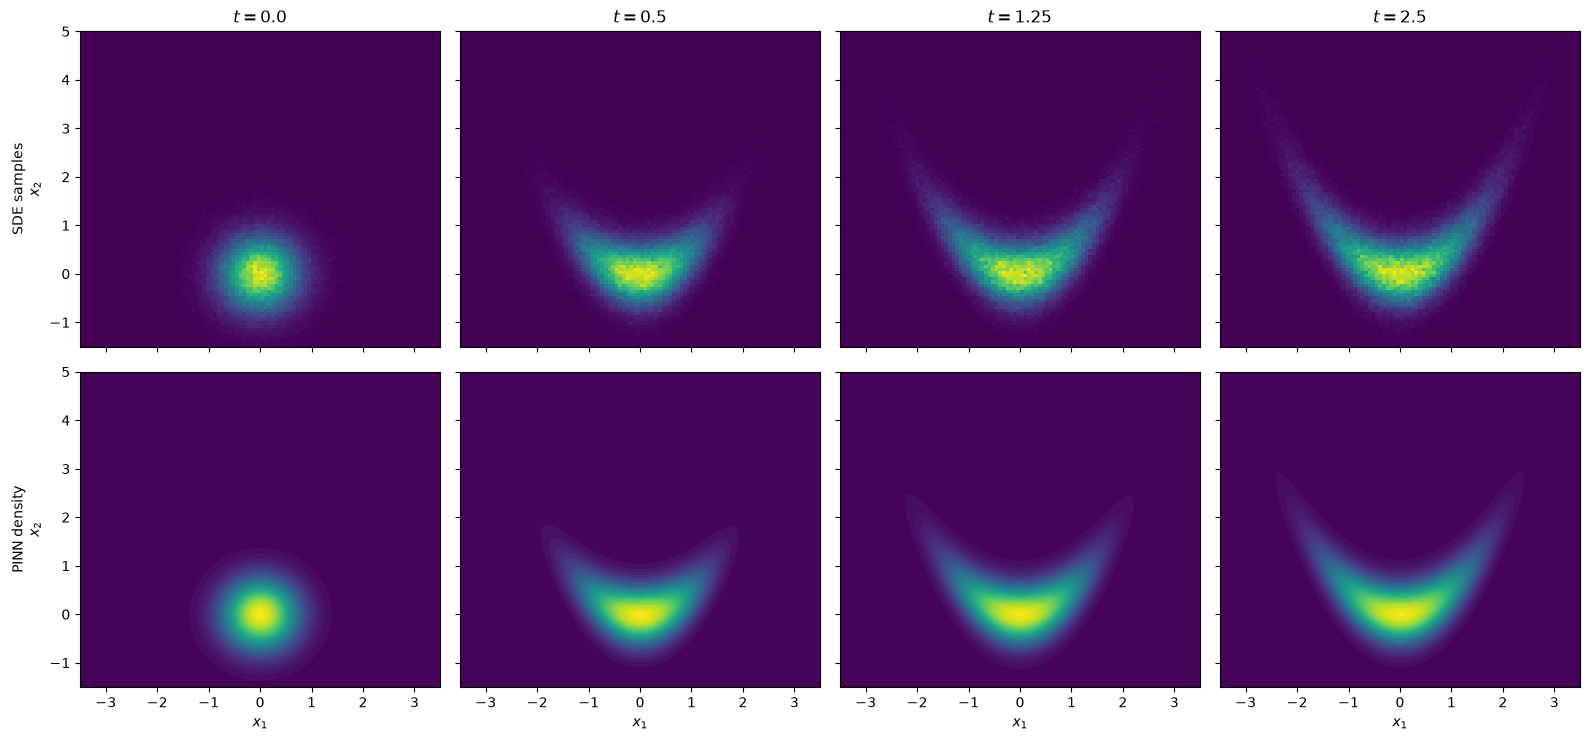

In [7]:
ng = 150
gx = torch.linspace(lo[0], hi[0], ng)
gy = torch.linspace(lo[1], hi[1], ng)
Xg, Yg = torch.meshgrid(gx, gy, indexing="ij")
grid = torch.stack([Xg.flatten(), Yg.flatten()], dim=1)
if d > 2:
    grid = torch.cat([grid, torch.zeros(grid.shape[0], d - 2)], dim=1)  # slice at x_k = 0

fig, axes = plt.subplots(2, len(t_snap), figsize=(4 * len(t_snap), 7.5), sharex=True, sharey=True)
for j, (ts, xs) in enumerate(zip(t_snap, snapshots)):
    axes[0, j].hist2d(xs[:, 0].numpy(), xs[:, 1].numpy(), bins=100,
                      range=[[lo[0], hi[0]], [lo[1], hi[1]]], density=True, cmap="viridis")
    axes[0, j].set_title(f"$t = {ts}$")
    with torch.no_grad():
        p_grid = pdf_model(ts * torch.ones(grid.shape[0], 1), grid).reshape(ng, ng)
    axes[1, j].contourf(Xg.numpy(), Yg.numpy(), p_grid.numpy(), levels=50, cmap="viridis")
axes[0, 0].set_ylabel("SDE samples\n$x_2$")
axes[1, 0].set_ylabel("PINN density\n$x_2$")
for ax in axes[1]:
    ax.set_xlabel("$x_1$")
plt.tight_layout()
plt.show()

## Moments and normalization

A quantitative check: the mean $\int x\, p_\theta(t, x)\,\mathrm{d}x$ of the learned density (by quadrature on the grid) against the sample mean, plus the integral $\int_\text{box} p_\theta(t, x)\,\mathrm{d}x$ — which should be $\approx 1$ without ever having been enforced during training.

In [8]:
cell = ((hi[0] - lo[0]) / ng * (hi[1] - lo[1]) / ng).item()
for ts, xs in zip(t_snap, snapshots):
    with torch.no_grad():
        p_grid = pdf_model(ts * torch.ones(grid.shape[0], 1), grid)
    w = p_grid * cell
    mean_pinn = (grid[:, :2] * w.unsqueeze(-1)).sum(0)
    mean_mc = xs[:, :2].mean(0)
    print(f"t = {ts:4.2f}   integral {w.sum():.3f}   "
          f"mean PINN ({mean_pinn[0]:+.3f}, {mean_pinn[1]:+.3f})   "
          f"mean MC ({mean_mc[0]:+.3f}, {mean_mc[1]:+.3f})")

t = 0.00   integral 0.986   mean PINN (+0.003, +0.000)   mean MC (-0.002, -0.001)
t = 0.50   integral 0.986   mean PINN (+0.004, +0.217)   mean MC (+0.004, +0.222)
t = 1.25   integral 0.986   mean PINN (-0.001, +0.305)   mean MC (+0.002, +0.345)
t = 2.50   integral 0.986   mean PINN (+0.015, +0.389)   mean MC (+0.004, +0.427)
